In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Machine learning con el calculo de farenheit a celcius (Caso lineal)

En el presente notebook se desarrolla la implementación de una neurona artificial desde cero, con el objetivo de modelar una relación lineal entre variables.

Como caso de utilizaestudio, se  la transformación de grados Celsius a Fahrenheit, descrita como:
# F = 1.8 * C + 32

El propósito principal es que la neurona logre aprender los parámetros de esta relación, identificando correctamente la pendiente (m)  y el sesgo (b) a partir de los datos. En este caso, se espera que el modelo converja hacia valores cercanos a ( m = 1.8 ) y ( b = 32 ), los cuales representan el comportamiento real del fenómeno.

In [52]:
class Tempredict():
    def __init__(self, learning_rate=0.1, epochs=1000):
        #Parametros
        self.learning_rate = learning_rate
        self.epochs = epochs
        #Parametros autoajustados
        self.m = 0.0
        self.b = 0.0

        #Función de perdida
        self.perdida=[]

        #Histroial:
        self.historial_m = []
        self.historial_b = []

    def prediccion(self, c):
      f_pre=[] #Esta lista vacia sirve para guardar los datos predecidos
      for i in c:
        resultado= self.m*i+self.b
        f_pre.append(resultado)
      return f_pre
    def ajustar(self, c, f):
        n = len(c)
        for epoch in range(self.epochs):
            f_pre = self.prediccion(c)
            dm = 0
            db = 0
            for i in range(n):
                error = f_pre[i] - f[i]
                dm += c[i] * error
                db += error
            dm = (2 / n) * dm
            db = (2 / n) * db
            mse = np.mean((np.array(f) - np.array(f_pre))**2)
            self.perdida.append(mse)
            self.m -= self.learning_rate * dm
            self.b -= self.learning_rate * db
            self.historial_m.append(self.m)
            self.historial_b.append(self.b)
            if epoch % 500 == 0:
                print (f"Epoch: {epoch}, Error: {mse}")

    def get_parametros(self):
        print(f"El valor de m es: {self.m}")
        print(f"El valor de b es: {self.b}")
        return self.m, self.b

In [63]:
class TempredictVisual(Tempredict):
    def __init__(self, learning_rate=0.1, epochs=1000):
        super().__init__(learning_rate, epochs)

    def graficar_perdida(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.perdida)
        plt.yscale('log')
        plt.title("Curva de pérdida (MSE vs épocas)")
        plt.xlabel("Épocas")
        plt.ylabel("MSE")
        plt.grid(True)
        plt.show()

    def graficar_ajuste(self, c_entr, f_entr, c_prueba, f_prueba, c_max, f_max):
        c_entr_real   = np.array(c_entr)   * c_max
        f_entr_real   = np.array(f_entr)   * f_max
        c_prueba_real = np.array(c_prueba) * c_max
        f_prueba_real = np.array(f_prueba) * f_max

        m_real = self.m * (f_max / c_max)
        b_real = self.b * f_max

        c_linea = np.linspace(min(c_entr_real.min(), c_prueba_real.min()),
                              max(c_entr_real.max(), c_prueba_real.max()), 100)
        f_linea = m_real * c_linea + b_real

        plt.figure(figsize=(8, 5))
        plt.scatter(c_entr_real,   f_entr_real,   label="Entrenamiento", marker='o', s=30)
        plt.scatter(c_prueba_real, f_prueba_real, label="Prueba",        marker='^', s=40, color='orange')
        plt.plot(c_linea, f_linea, color='tomato', linewidth=2, label="Modelo aprendido")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Ajuste del modelo (escala real)")
        plt.legend()
        plt.grid(True)
        plt.show()
    def graficar_superficie(self, c_entr, f_entr, c_max, f_max):
        c_real = np.array(c_entr) * c_max
        f_real = np.array(f_entr) * f_max

        tray_m = [m * (f_max / c_max) for m in self.historial_m]
        tray_b = [b * f_max           for b in self.historial_b]

        m_vals = np.linspace(min(tray_m) - 0.5, max(tray_m) + 0.5, 100)
        b_vals = np.linspace(min(tray_b) - 5,   max(tray_b) + 5,   100)
        M, B   = np.meshgrid(m_vals, b_vals)

        L = np.zeros_like(M)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                y_pred  = M[i, j] * c_real + B[i, j]
                L[i, j] = np.mean((f_real - y_pred) ** 2)

        tray_loss = []
        for mi, bi in zip(tray_m, tray_b):
            y_pred = mi * c_real + bi
            tray_loss.append(np.mean((f_real - y_pred) ** 2))

        import plotly.graph_objects as go

        fig = go.Figure()
        fig.add_trace(go.Surface(x=M, y=B, z=L, colorscale='Viridis', opacity=0.7, name='Pérdida'))
        fig.add_trace(go.Scatter3d(
            x=tray_m, y=tray_b, z=tray_loss,
            mode='lines', line=dict(color='tomato', width=3), name='Trayectoria'
        ))
        fig.add_trace(go.Scatter3d(
            x=[tray_m[0]], y=[tray_b[0]], z=[tray_loss[0]],
            mode='markers', marker=dict(color='white', size=5), name='Inicio'
        ))
        fig.add_trace(go.Scatter3d(
            x=[tray_m[-1]], y=[tray_b[-1]], z=[tray_loss[-1]],
            mode='markers', marker=dict(color='yellow', size=5), name='Final'
        ))
        fig.update_layout(
            title='Superficie de pérdida 3D y trayectoria del gradiente',
            scene=dict(xaxis_title='m', yaxis_title='b', zaxis_title='MSE')
        )
        fig.show()

    def graficar_mapa_calor(self, c_entr, f_entr, c_max, f_max):
        c_real = np.array(c_entr) * c_max
        f_real = np.array(f_entr) * f_max

        # Trayectoria primero, antes de usarla en linspace
        tray_m = [m * (f_max / c_max) for m in self.historial_m]
        tray_b = [b * f_max           for b in self.historial_b]

        m_vals = np.linspace(min(tray_m) - 0.5, max(tray_m) + 0.5, 200)
        b_vals = np.linspace(min(tray_b) - 5,   max(tray_b) + 5,   200)
        M, B   = np.meshgrid(m_vals, b_vals)

        L = np.zeros_like(M)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                y_pred  = M[i, j] * c_real + B[i, j]
                L[i, j] = np.mean((f_real - y_pred) ** 2)

        plt.figure(figsize=(8, 6))
        cp = plt.contourf(M, B, L, levels=50, cmap='viridis')
        plt.colorbar(cp, label='MSE')
        plt.contour(M, B, L, levels=50, colors='white', linewidths=0.3, alpha=0.3)
        plt.plot(tray_m, tray_b, color='tomato', linewidth=1.5, label='Trayectoria')
        plt.scatter(tray_m[0],  tray_b[0],  color='white',  zorder=5, s=60, label='Inicio')
        plt.scatter(tray_m[-1], tray_b[-1], color='yellow', zorder=5, s=60, label='Final')
        plt.xlabel('m')
        plt.ylabel('b')
        plt.title('Mapa de calor de la superficie de pérdida')
        plt.legend()
        plt.grid(False)
        plt.show()

In [ ]:
celsius = list(range(0, 101, 5))
fahrenheit = [c * 1.8 + 32 for c in celsius]

Actualmente en esa lista los datos están ordenados de mayor a menor, entonces, al dividir 80% para el entrenamiento y 20% para la prueba, el modelo veía durante el entrenamiento solo las temperaturas bajas (de 0 a ~80°C) y nunca las altas. Cuando llegaba el momento de probarlo, se le prensentaban temperaturas que nunca había visto y predecía mal, por eso la línea no ajustaba bien con los triángulos naranjas en la gráfica.

In [ ]:
# Mezclar aleatoriamente
indices = np.random.permutation(len(celsius))
celsius_shuffle = [celsius[i] for i in indices]
fahrenheit_shuffle = [fahrenheit[i] for i in indices]

### Celcius y farenheit viven en escalas MUY distintas, Esto generaba una disparidad tremenda entre los datos. Sucedia lo siguiente:

Cuando el modelo calculaba el gradiente de m, lo multiplicaba por los valores de celsius (hasta 45). El gradiente de b no tenía ese multiplicador. Eso hacía que m recibiera empujones enormes comparado con b, y el modelo se desestabilizaba.

Para solucionar este error, se necesita encontrar un punto medio, y que mejora que normalizar estos valores para que queden entre 0 a 1 y los gradientes se vuelvan comparables en magnitud, lo que hacia que funcionara el decenso.

In [ ]:
# Normalizas dividiendo por el máximo
c_max = max(celsius)#45
f_max = max(fahrenheit) #113
# valores entre 0 y 1
celsius_norm    = [c / c_max for c in celsius]
fahrenheit_norm = [f / f_max for f in fahrenheit]

Lo que se hizo fue dividir cada valor de sus respectivos arreglos por el maximo de cada uno respectivamente.

In [ ]:
temperatura1 = Tempredict(learning_rate=0.01, epochs=5000)
temperatura1.ajustar(celsius_norm, fahrenheit_norm)
temperatura1.get_parametros()

Epoch: 0, Error: 0.397249911000356
Epoch: 500, Error: 0.007773186734042088
Epoch: 1000, Error: 0.0018320759477379236
Epoch: 1500, Error: 0.0004318051777460547
Epoch: 2000, Error: 0.0001017729159964775
Epoch: 2500, Error: 2.3987036201120673e-05
Epoch: 3000, Error: 5.653546428145138e-06
Epoch: 3500, Error: 1.3324942250977254e-06
Epoch: 4000, Error: 3.140578895893488e-07
Epoch: 4500, Error: 7.402085213999279e-08
El valor de m es: 0.848623905162799
El valor de b es: 0.15117658385478627


(0.848623905162799, 0.15117658385478627)

Tenemos un learning_rate= 0.01, se puede confirmar que está bien parametrado debido a la normalización que se le hizo previamente a cada uno de los arreglos.

Tenemos 5000 epochs que, serviran para que la neurona se vaya auto ajustando

In [ ]:
m_norm, b_norm = temperatura1.get_parametros()

m_real = m_norm * (f_max / c_max)
b_real = b_norm * f_max

print(f"m real: {m_real}")
print(f"b real: {b_real}")

El valor de m es: 0.848623905162799
El valor de b es: 0.15117658385478627
m real: 1.799082678945134
b real: 32.04943577721469


Lo que se hizo fue tomar la ecuación que el modelo aprendió en el espacio normalizado.
Luego se despeja $f$ multiplicando ambos lados por $f_{\max}$.
Como esta ecuación tiene la misma forma que $f = m \cdot c + b$, se compara término a término.


En conclusión, el modelo aprende la misma relación, pero en un sistema de coordenadas escalado. Luego, ese escalado se revierte para volver a las unidades originales.

## Graficación del algoritmo sin ruido

In [ ]:
# División 80/20
split = int(0.8 * len(celsius_norm))
c_entr = celsius_norm[:split]
f_entr = fahrenheit_norm[:split]
c_prueba = celsius_norm[split:]
f_prueba = fahrenheit_norm[split:]

En esta celda se realiza la separación del conjunto de datos en dos partes: entrenamiento y prueba. Primero se calcula el índice correspondiente al 80% del total de datos. Luego, se toman los valores desde el inicio hasta ese punto para conformar el conjunto de entrenamiento, y los valores restantes se asignan al conjunto de prueba. De esta forma, el modelo se entrena con una parte de los datos y posteriormente se evalúa con información que no utilizó durante el entrenamiento.

Epoch: 0, Error: 0.2585773406906372
Epoch: 500, Error: 0.009902189188847376
Epoch: 1000, Error: 0.003921060040211465
Epoch: 1500, Error: 0.0015526578593580984
Epoch: 2000, Error: 0.0006148200750571791
Epoch: 2500, Error: 0.00024345590524984834
Epoch: 3000, Error: 9.640345233605246e-05
Epoch: 3500, Error: 3.817375311874914e-05
Epoch: 4000, Error: 1.5116008730595037e-05
Epoch: 4500, Error: 5.985623662222051e-06
El valor de m es: 0.8423978808530436
El valor de b es: 0.1535616372815649


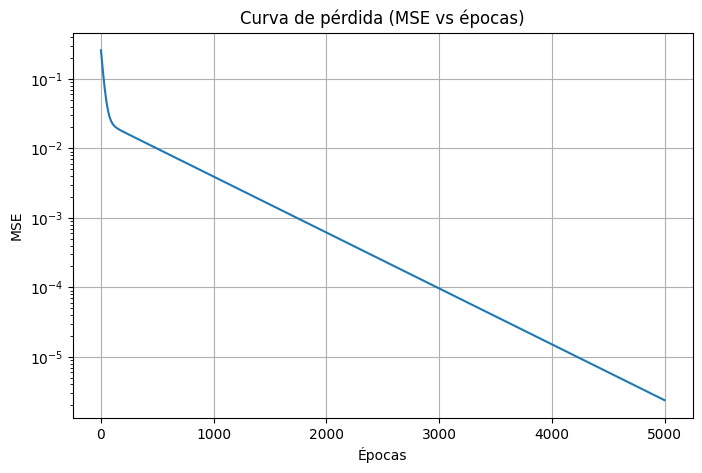

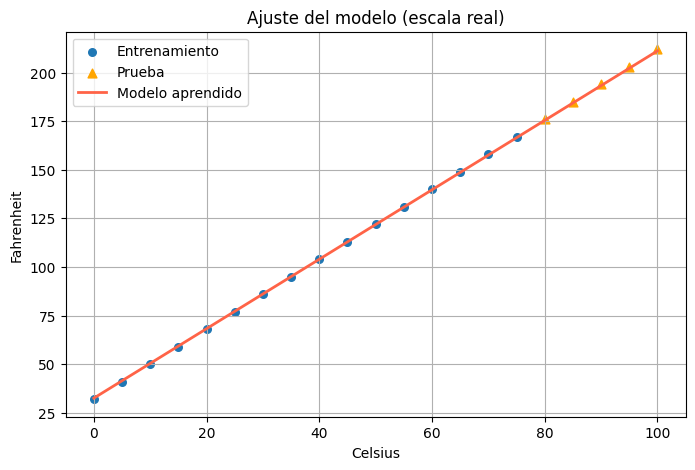

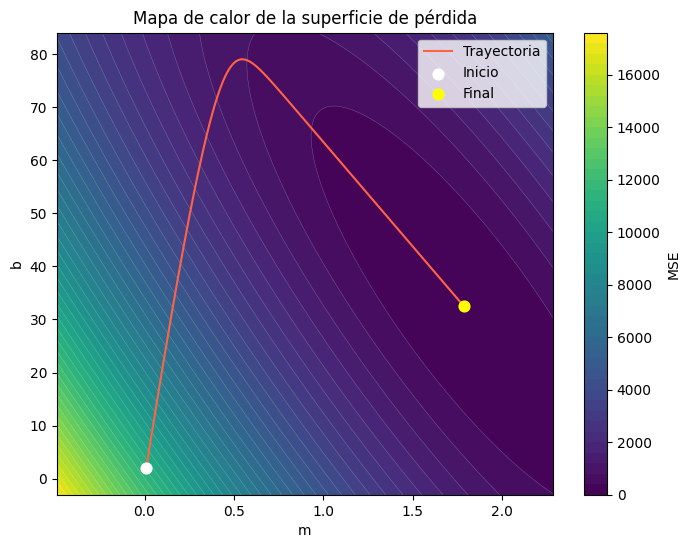

In [62]:
modelo = TempredictVisual(learning_rate=0.01, epochs=5000)
modelo.ajustar(c_entr, f_entr)
modelo.get_parametros()
modelo.graficar_perdida()
modelo.graficar_ajuste(c_entr, f_entr, c_prueba, f_prueba, c_max, f_max)
modelo.graficar_superficie(c_entr, f_entr, c_max, f_max)
modelo.graficar_mapa_calor(c_entr, f_entr, c_max, f_max)

# Entrenamiento con ruido

Utilizaremos las mismas dos clases anteriormente usadas para calcular los coeficientes m y b en la ecuacion de la transformacion de farenheit a celsius.

In [64]:
np.random.seed(42)

N = 200
m_verdadero = 2.5
c_verdadero = -1

x = np.linspace(-5, 5, N)

# Dos niveles de ruido
sigma_bajo = 1
sigma_alto = 6

ruido_bajo = np.random.normal(0, sigma_bajo, size=N)
ruido_alto = np.random.normal(0, sigma_alto, size=N)

y_bajo = m_verdadero * x + c_verdadero + ruido_bajo
y_alto = m_verdadero * x + c_verdadero + ruido_alto

In [65]:
def preparar_datos(x, y):
    indices = np.random.permutation(len(x))
    x_s = x[indices]
    y_s = y[indices]

    x_max = max(abs(x_s))
    y_max = max(abs(y_s))

    x_norm = x_s / x_max
    y_norm = y_s / y_max

    split = int(0.8 * N)
    return (list(x_norm[:split]), list(y_norm[:split]),
            list(x_norm[split:]), list(y_norm[split:]),
            x_max, y_max)

x_entr_b, y_entr_b, x_prueba_b, y_prueba_b, x_max_b, y_max_b = preparar_datos(x, y_bajo)
x_entr_a, y_entr_a, x_prueba_a, y_prueba_a, x_max_a, y_max_a = preparar_datos(x, y_alto)

### Entrenamiento con ruido bajo:

Epoch: 0, Error: 0.28691832187231425
Epoch: 500, Error: 0.004945895784863945
Epoch: 1000, Error: 0.004578128485145242
Epoch: 1500, Error: 0.004577642602402958
Epoch: 2000, Error: 0.0045776419604697475
Epoch: 2500, Error: 0.0045776419596216455
Epoch: 3000, Error: 0.004577641959620525
Epoch: 3500, Error: 0.004577641959620524
Epoch: 4000, Error: 0.004577641959620524
Epoch: 4500, Error: 0.004577641959620524
El valor de m es: 0.9171179391933183
El valor de b es: -0.07881974071502755


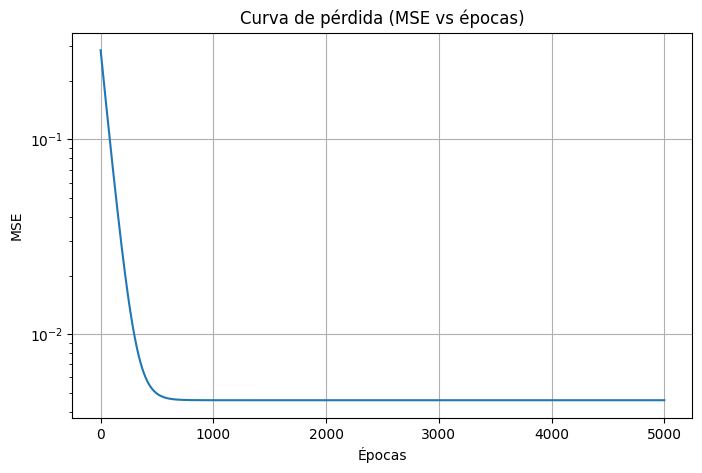

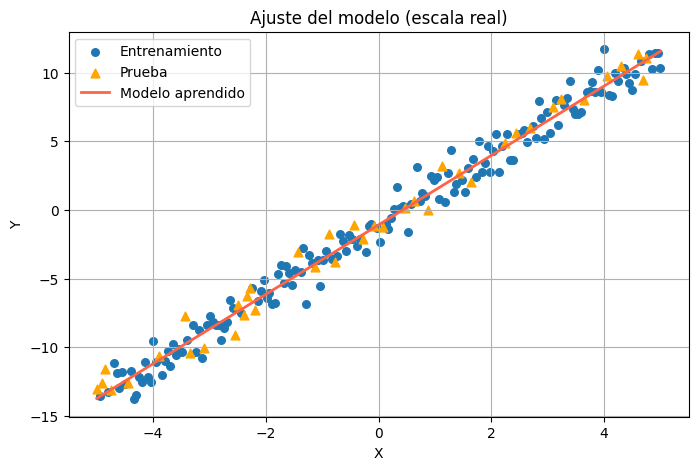

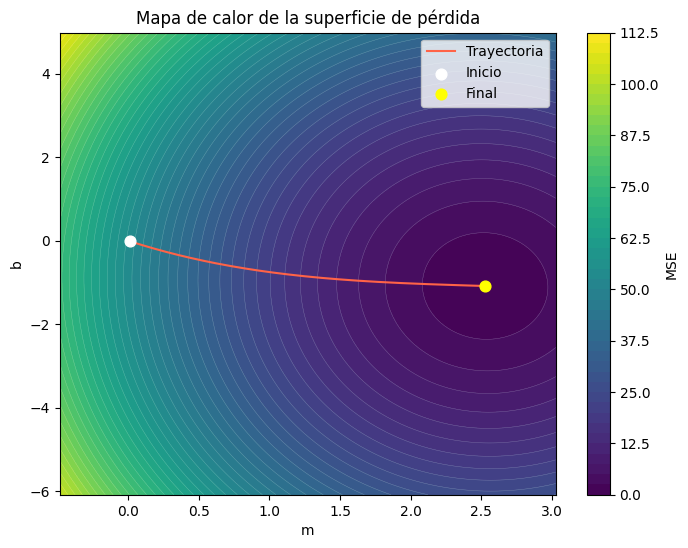

In [66]:
modelo_bajo = TempredictVisual(learning_rate=0.01, epochs=5000)
modelo_bajo.ajustar(x_entr_b, y_entr_b)
modelo_bajo.get_parametros()
modelo_bajo.graficar_perdida()
modelo_bajo.graficar_ajuste(x_entr_b, y_entr_b, x_prueba_b, y_prueba_b, x_max_b, y_max_b)
modelo_bajo.graficar_superficie(x_entr_b, y_entr_b, x_max_b, y_max_b)
modelo_bajo.graficar_mapa_calor(x_entr_b, y_entr_b, x_max_b, y_max_b)

### Entrenamiento con ruido alto:

Epoch: 0, Error: 0.13156691149715485
Epoch: 500, Error: 0.054262408328591194
Epoch: 1000, Error: 0.0541309914328158
Epoch: 1500, Error: 0.05413076326238485
Epoch: 2000, Error: 0.05413076286622768
Epoch: 2500, Error: 0.05413076286553985
Epoch: 3000, Error: 0.05413076286553866
Epoch: 3500, Error: 0.05413076286553866
Epoch: 4000, Error: 0.05413076286553866
Epoch: 4500, Error: 0.05413076286553866
El valor de m es: 0.49042922493478175
El valor de b es: -0.02083728516463326


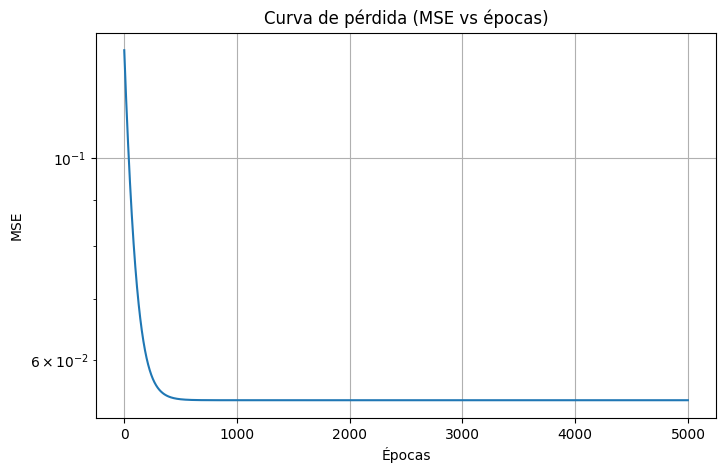

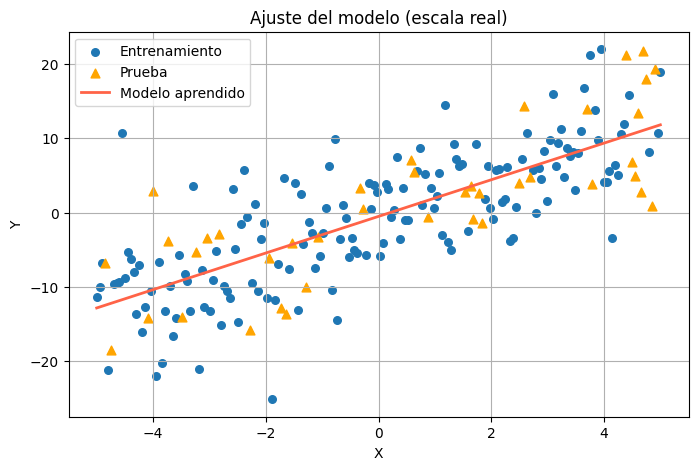

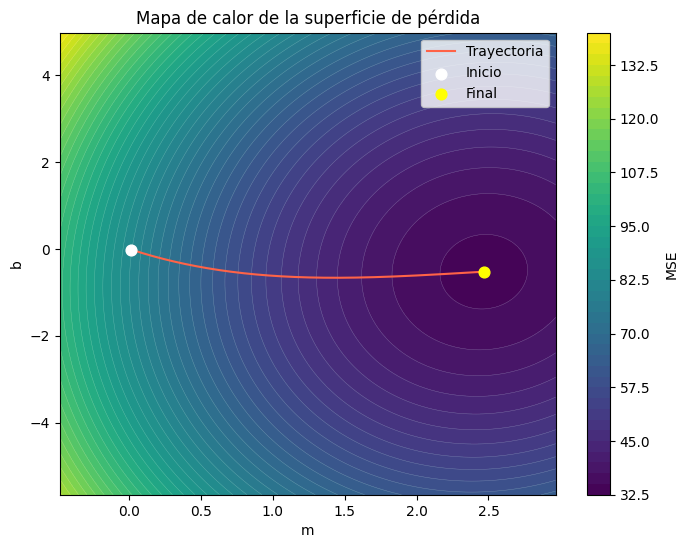

In [67]:
modelo_alto = TempredictVisual(learning_rate=0.01, epochs=5000)
modelo_alto.ajustar(x_entr_a, y_entr_a)
modelo_alto.get_parametros()
modelo_alto.graficar_perdida()
modelo_alto.graficar_ajuste(x_entr_a, y_entr_a, x_prueba_a, y_prueba_a, x_max_a, y_max_a)
modelo_alto.graficar_superficie(x_entr_a, y_entr_a, x_max_a, y_max_a)
modelo_alto.graficar_mapa_calor(x_entr_a, y_entr_a, x_max_a, y_max_a)